In [2]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Montar el Drive
drive.mount('/content/drive')

# 1. Cargar el progreso
df_day5 = pd.read_csv('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/df_dia4_consolidado.csv')

Mounted at /content/drive


In [3]:
# Clasificar condados por perfil profesional (Umbral del 30% según el video)
df_day5['Nodo_Estrategico'] = df_day5['Professional'].apply(
    lambda x: 'Nodo A (Conocimiento)' if x > 30 else 'Nodo B (Industrial)'
)

# Guardar la versión final absoluta
df_day5.to_csv('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/ENTREGA_FINAL_DIA5.csv', index=False)
print("✅ Archivo final generado con segmentación de Nodos.")

✅ Archivo final generado con segmentación de Nodos.


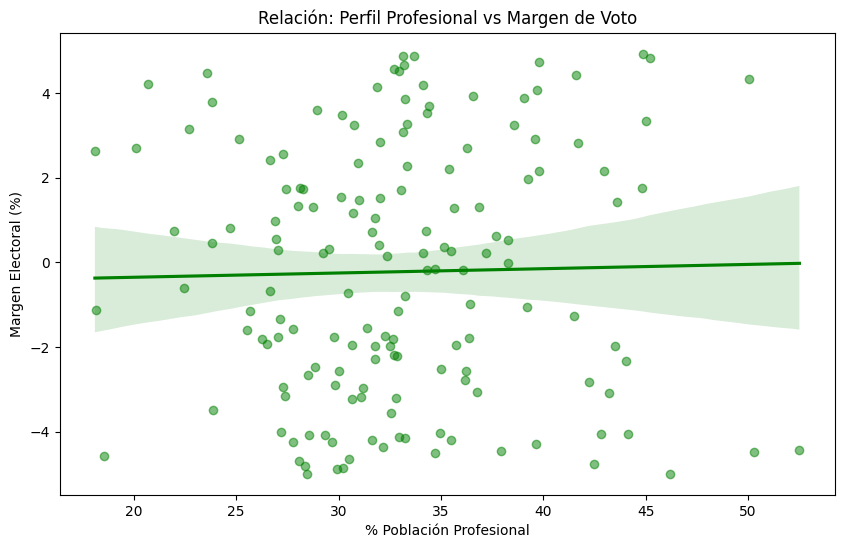

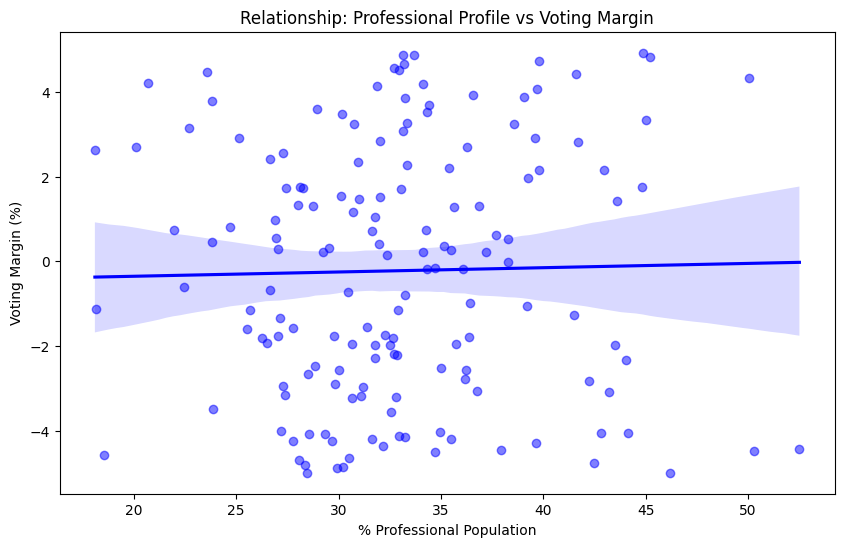

In [4]:
# --- GRÁFICA DE REGRESIÓN (ESPAÑOL) ---
plt.figure(figsize=(10,6))
sns.regplot(data=df_day5, x='Professional', y='margen_perc', color='green', scatter_kws={'alpha':0.5})
plt.title('Relación: Perfil Profesional vs Margen de Voto')
plt.xlabel('% Población Profesional')
plt.ylabel('Margen Electoral (%)')
plt.savefig('grafica_final_ES.png')

# --- GRÁFICA DE REGRESIÓN (INGLÉS) ---
plt.figure(figsize=(10,6))
sns.regplot(data=df_day5, x='Professional', y='margen_perc', color='blue', scatter_kws={'alpha':0.5})
plt.title('Relationship: Professional Profile vs Voting Margin')
plt.xlabel('% Professional Population')
plt.ylabel('Voting Margin (%)')
plt.savefig('grafica_final_EN.png')

In [5]:
# 1. Conteo de Nodos para el presupuesto
print(df_day5['Nodo_Estrategico'].value_counts())

# 2. Los 5 condados más críticos (margen más bajo) para "mencionar" en la junta
print(df_day5.nsmallest(5, 'distancia_al_cero')[['state_name', 'Nodo_Estrategico', 'margen_perc']])

Nodo_Estrategico
Nodo A (Conocimiento)    105
Nodo B (Industrial)       51
Name: count, dtype: int64
    state_name       Nodo_Estrategico  margen_perc
89    New York  Nodo A (Conocimiento)    -0.024111
5   California  Nodo A (Conocimiento)     0.151286
93    New York  Nodo A (Conocimiento)    -0.161286
61   Minnesota  Nodo A (Conocimiento)    -0.177824
90    New York  Nodo A (Conocimiento)    -0.183876


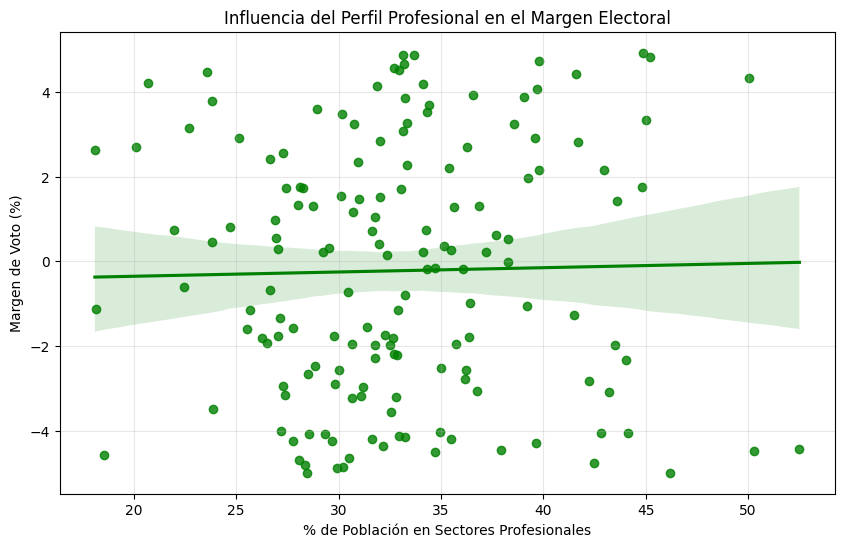

In [6]:
# Gráfica Final en Español
plt.figure(figsize=(10,6))
sns.regplot(data=df_day5, x='Professional', y='margen_perc', color='green')
plt.title('Influencia del Perfil Profesional en el Margen Electoral')
plt.xlabel('% de Población en Sectores Profesionales')
plt.ylabel('Margen de Voto (%)')
plt.grid(True, alpha=0.3)
plt.savefig('grafica_dia5_es.png', dpi=300)

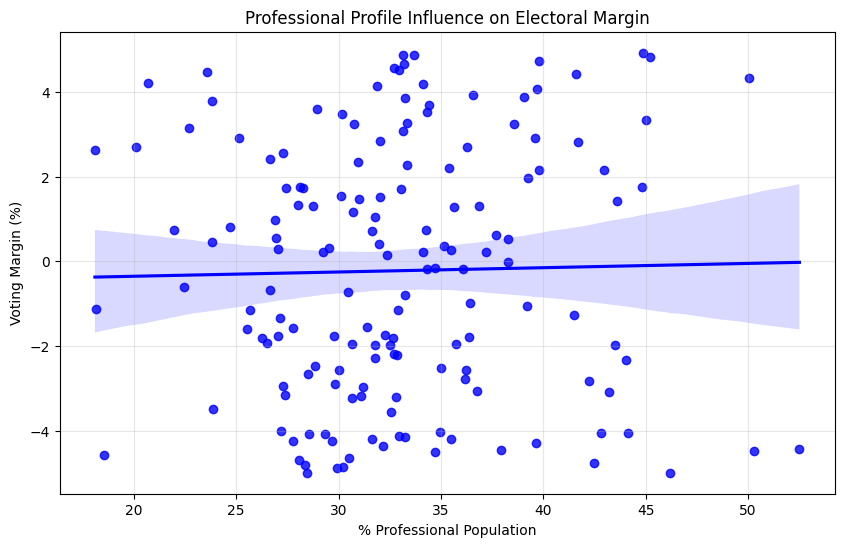

In [7]:
# Gráfica Final en Inglés
plt.figure(figsize=(10,6))
sns.regplot(data=df_day5, x='Professional', y='margen_perc', color='blue')
plt.title('Professional Profile Influence on Electoral Margin')
plt.xlabel('% Professional Population')
plt.ylabel('Voting Margin (%)')
plt.grid(True, alpha=0.3)
plt.savefig('grafica_dia5_en.png', dpi=300)